# Machine Learning Workflow Practice
Follow _Data Science Handbook_ Ch. 5  [Introducing Scikit-Learn](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/05.02-Introducing-Scikit-Learn.ipynb) (p.343-354):

## Feature matrix and target vector
![](images/05.02-samples-features.png)

## The five steps
1. Load and arrange data into feature matrix and target vector
2. Choose model class
3. Instantiate model
4. Fit model to data
5. Predict values for new data and evaluate results

Note the re-ordering of the steps with respect to the text

## Supervised Learning: Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load and arrange data

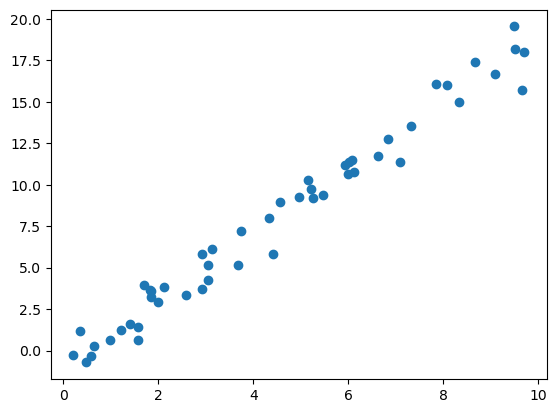

In [2]:
rng = np.random.RandomState(42)
x = 10 * rng.rand(50)
y = 2 * x - 1 + rng.randn(50)
plt.scatter(x,y);

In [3]:
x.shape

(50,)

The shape of the feature matrix needs to be 50 rows and 1 column (50 data samples with one feature each). The feature matrix cannot be represented as a vector as this will give an error when you try to fit the model to the data

In [4]:
X = x[:, np.newaxis]
X.shape

(50, 1)

In [5]:
X = x[:, None]
X.shape

(50, 1)

In [6]:
y.shape

(50,)

### 2. Choose model class
For this example, the data seems to be linear, so we will try Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression

### 3. Instatiate model and select hyperparameters 

In [8]:
model = LinearRegression(fit_intercept=True)
model

LinearRegression()

### 4. Fit the model to your data 

In [9]:
model.fit(X, y)

LinearRegression()

In [10]:
model.coef_ # Based on formula, the true value of the slope is 2.0

array([1.9776566])

In [11]:
model.intercept_ # Based on formula, the true value of the intercept is -1.0

-0.9033107255311146

### 5. Predict labels for unknown data

In [12]:
# Creating unknown data
xfit = np.linspace(-1, 11)
Xfit = xfit[:, None]

In [13]:
# Predicting labels for unknown data
yfit = model.predict(Xfit)

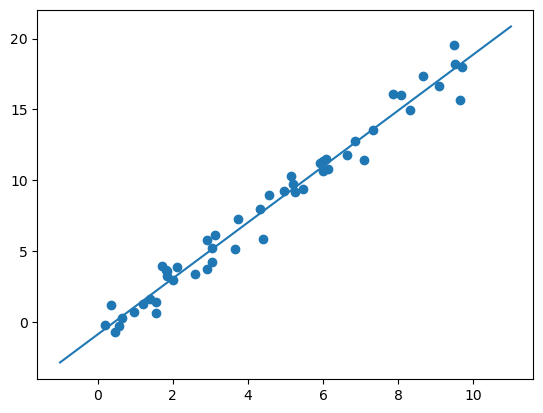

In [14]:
plt.scatter(x, y)
plt.plot(xfit, yfit)

Check model performance with accuracy metrics:

In [15]:
# For regression, we typically use mean squared error
from sklearn.metrics import mean_squared_error

mean_squared_error(y, yfit)

87.04102889045718

In [16]:
# default regression metric for score method is r-squared
model.score(X, y)

0.9749140085676858

## Supervised Learning: Classification 

### Step 1. Load and arrange data

In [17]:
iris = sns.load_dataset('iris')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [18]:
X_iris = iris.drop('species', axis=1)
X_iris.shape

(150, 4)

In [19]:
y_iris = iris['species']
y_iris.shape

(150,)

Leave out some data, a test set, to evaluate the model on:

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, random_state=1)

### Steps 2 - 5: 
**Question:** What are the steps?

**Answer:**



For this case, we are going to try another classification model, Gaussian Naive Bayes (NB):

In [21]:
from sklearn.naive_bayes import GaussianNB
# TO DO: Step 2 - 5
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9736842105263158

In [23]:
model.score(X_test, y_test)

0.9736842105263158

### Confusion matrix
From the digits example later in the text. How do we evaluate what predictions we got wrong?

Text(113.9222222222222, 0.5, 'true value')

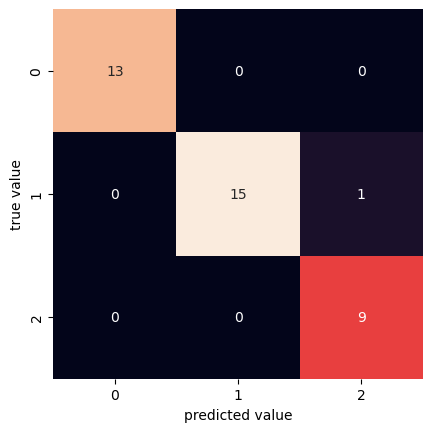

In [24]:
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(y_test, y_pred)

sns.heatmap(mat, square=True, annot=True, cbar=False)
plt.xlabel('predicted value')
plt.ylabel('true value')

In this case, we only made one mistake